# 1. Choosing learning tasks - A multi-task image classification problem with two categorical outputs.
- Acivity and time of day labels were chosen since they are insightful and have potential.
- Also, mood is a good choice with them to be predicted but it is avoided due to the fear of over kill.

# 2. Data Preprocessing and Exploratory Data Analysis (EDA)

## 2.1 dataset extraction and consolidation pipeline
- Extracts and merges all dataset files into a single consistent dataset for modeling named as "final_complete_dataset.csv"
- Extracts the main ZIP file
- Extracts nested ZIP files (if any)
- Finds the “general” file and uses it as the column schema
- Reads all other CSV files
- Keeps only valid columns
- Skips broken or incompatible files
- Merges everything into one clean CSV
- Removes duplicates
- Saves a final dataset

In [1]:
from pathlib import Path
import zipfile
import pandas as pd

# =========================
# 1) SET THESE ONLY
# =========================
data_dir = Path(r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3") 
zip_path   = data_dir / "compressed_attachments.zip"
extract_dir = data_dir / "extracted_dataset"
out_csv    = data_dir / "final_complete_dataset.csv"

extract_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 2) UNZIP main zip + any nested zips
# =========================
def extract_zip(zpath: Path, outdir: Path):
  with zipfile.ZipFile(zpath, "r") as z:
    z.extractall(outdir)

extract_zip(zip_path, extract_dir)

# extract nested zips (if inside the main zip)
done = set()
while True:
  nested = [p for p in extract_dir.rglob("*.zip") if p not in done]
  if not nested:
    break
  for nz in nested:
    target = nz.parent / nz.stem
    target.mkdir(exist_ok=True)
    extract_zip(nz, target)
    done.add(nz)

# =========================
# 3) READ "GENERAL FILE" (used as the column schema)
# =========================
def clean_cols(df: pd.DataFrame) -> pd.DataFrame:
  df.columns = [str(c).strip() for c in df.columns]
  return df

def read_csv_robust(p: Path) -> pd.DataFrame:
  # tries common safe options without adding extra columns
  try:
    return pd.read_csv(p)
  except Exception:
    try:
      return pd.read_csv(p, sep=None, engine="python", encoding_errors="replace")
    except Exception:
      return pd.read_csv(p, sep=None, engine="python", encoding="latin1", encoding_errors="replace")

def pick_general_file(root: Path) -> Path:
  # prefer a file with "general" in its name; otherwise pick the largest top-level csv/xlsx
  top = [p for p in root.iterdir() if p.is_file() and p.suffix.lower() in [".csv", ".xlsx", ".xls"]]
  if top:
    general_named = [p for p in top if "general" in p.name.lower()]
    candidates = general_named if general_named else top
    return max(candidates, key=lambda x: x.stat().st_size)

  # fallback: search anywhere
  all_files = [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in [".csv", ".xlsx", ".xls"]]
  if not all_files:
    raise FileNotFoundError("No CSV/XLSX found after extraction.")
  general_named = [p for p in all_files if "general" in p.name.lower()]
  candidates = general_named if general_named else all_files
  return max(candidates, key=lambda x: x.stat().st_size)

general_path = pick_general_file(extract_dir)

if general_path.suffix.lower() in [".xlsx", ".xls"]:
  general_df = pd.read_excel(general_path)
else:
  general_df = read_csv_robust(general_path)

general_df = clean_cols(general_df)
schema_cols = list(general_df.columns)  # <-- the ONLY columns we keep in the final dataset

print("General file:", general_path.name)
print("Schema columns count:", len(schema_cols))

# =========================
# 4) READ ALL OTHER CSVs, KEEP ONLY SCHEMA COLUMNS, CONCAT
# =========================
csv_files = [p for p in extract_dir.rglob("*.csv")]

# exclude the general file if it is csv
if general_path.suffix.lower() == ".csv":
  csv_files = [p for p in csv_files if p.resolve() != general_path.resolve()]

dfs = [general_df[schema_cols].copy()]  # keep only schema columns (no extras)
skipped = []

for p in csv_files:
  try:
    df = read_csv_robust(p)
    df = clean_cols(df)

    # only accept files that contain ALL schema columns
    if not set(schema_cols).issubset(set(df.columns)):
      skipped.append((p.name, "missing schema columns"))
      continue

    df = df[schema_cols]  # drop any extra columns (no nonsense columns added)
    dfs.append(df)

  except Exception as e:
    skipped.append((p.name, str(e)))

combined_df = pd.concat(dfs, ignore_index=True).drop_duplicates()

print("Loaded files:", 1 + len(dfs) - 1)
print("Skipped files:", len(skipped))
if skipped:
  print("First 10 skipped:")
  for s in skipped[:10]:
    print(" -", s[0], "=>", s[1])

# =========================
# 5) SAVE ONE COMPLETE DATASET
# =========================
combined_df.to_csv(out_csv, index=False)
print("Saved combined dataset to:", out_csv)
print("Final shape:", combined_df.shape)
display(combined_df.head())

General file: 2934700-1211642.xlsx
Schema columns count: 8
Loaded files: 64
Skipped files: 57
First 10 skipped:
 - 2938327-StudentID.csv => missing schema columns
 - 2938317-HalaMosafer1202223.csv => missing schema columns
 - 2935939-1203048.csv => missing schema columns
 - 2935410-1210221.csv => missing schema columns
 - 2938460-1210249.csv => missing schema columns
 - 2938501-1210420.csv => Expected 4 fields in line 4, saw 6
 - 2938133-1210582.csv => missing schema columns
 - 2938343-1210904.csv => missing schema columns
 - 2938362-1210904.csv => missing schema columns
 - 2938368-1210904.csv => missing schema columns
Saved combined dataset to: D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset.csv
Final shape: (604, 8)


,Image URL,Description,Country,Weather,Time of Day,Season,Activity,Mood/Emotion
0,https://images.pexels.com/photos/2467552/pexel...,The Eiffel Tower stands as an iconic symbol of...,France,Cloudy,Afternoon,Spring,Sightseeing,Excitement
1,https://images.pexels.com/photos/1707310/pexel...,Burj Khalifa surrounded by lights and people. ...,United Arab Emirates,Cloudy,Evening,Winter,Sightseeing,Happiness
2,https://images.pexels.com/photos/34936504/pexe...,A peaceful autumn scene at Inokashira Park in ...,Japan,Sunny,Afternoon,Fall,Relaxing,Romance
3,https://vegantravellife.com/wp-content/uploads...,A peaceful hiking trail in Collserola Natural ...,Spain,Sunny,Morning,Spring,Hiking,Adventure
4,https://blog.donaldyip.com/wp-content/uploads/...,"Hallstatt, a picturesque lakeside village fram...",Austria,Snowy,Evening,Winter,Sightseeing,Excitement


## 2.2 Dataset Cleaning and Preprocessing 
- Loaded the original dataset containing image URLs and categorical labels.
- Standardized the *Activity* column by replacing missing or empty values with a unified `"no activity"` category.
- Filtered the *Time of Day* column to retain only valid categories: **Morning**, **Afternoon**, and **Evening**.
- Removed samples with invalid or unsupported time-of-day values and stored them separately for transparency.
- Normalized all categorical label columns to ensure consistency.
- Removed leading and trailing whitespace and standardized spacing.
- Converted all labels to lowercase to avoid case-sensitive duplication.
- Verified the number of unique activity and time-of-day classes after normalization.
- Created a clean dataset with a unique ID assigned to each remaining sample.
- Saved both the cleaned dataset and the deleted rows (with deletion reasons) for reproducibility and analysis.


In [10]:
import pandas as pd
import requests
from pathlib import Path
from urllib.parse import urlparse
from concurrent.futures import ThreadPoolExecutor, as_completed

# =========================
# 1) PATHS
# =========================
data_dir = Path(r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3")
in_csv  = data_dir / "final_complete_dataset.csv"

clean_csv   = data_dir / "final_complete_dataset_preprocessed.csv"
deleted_csv = data_dir / "final_complete_dataset_deleted_rows.csv"

# =========================
# 2) LOAD
# =========================
df0 = pd.read_csv(in_csv)

# Your exact column names
url_col = "Image URL"
activity_col = "Activity"
time_col = "Time of Day"   # keep ONLY Morning/Evening/Afternoon (case-insensitive)

# Only for deleted file (NOT in clean dataset)
reason_col = "_delete_reason"

# collect deleted rows from different rules
deleted_parts = []

# =========================
# 3) RULE: Activity empty -> "None"  (NOT a deletion)
# =========================
df = df0.copy()
df[activity_col] = df[activity_col].fillna("").astype(str).str.strip()
df.loc[df[activity_col].eq("") | df[activity_col].str.lower().eq("nan"), activity_col] = "no activity"

# =========================
# 4) RULE: Time of Day
#    KEEP rows if Time of Day is Morning/Evening/Afternoon (case-insensitive)
#    DELETE all other values
# =========================
if time_col in df.columns:
  tod = df[time_col].fillna("").astype(str).str.strip().str.lower()
  allowed_tod = {"morning", "evening", "afternoon"}

  invalid_tod_mask = ~tod.isin(allowed_tod)
  if invalid_tod_mask.any():
    df_tod_deleted = df.loc[invalid_tod_mask].copy()
    df_tod_deleted[reason_col] = "time_of_day_not_morning_evening_afternoon"
    deleted_parts.append(df_tod_deleted)

  df = df.loc[~invalid_tod_mask].copy()

# Normalize text columns (case-insensitive)
def normalize(s):
    return (
        s.astype(str)
         .str.strip()
         .str.replace(r"\s+", " ", regex=True)
         .str.lower()
    )

df["Activity"] = normalize(df["Activity"])
df["Time of Day"] = normalize(df["Time of Day"])

print("Dataset shape:", df.shape)
print("\nUnique activities:", df["Activity"].nunique())
print("Unique times of day:", df["Time of Day"].nunique())
# =========================
# 5) SAVE OUTPUTS
# =========================
# Clean dataset (NO extra columns)
# Add a new column 'id' starting from 1
df.insert(0, "id", range(1, len(df) + 1))
df.to_csv(clean_csv, index=False)

# Deleted rows dataset (includes reason column)
if deleted_parts:
  df_deleted = pd.concat(deleted_parts, ignore_index=True)
else:
  df_deleted = df0.head(0).copy()
  df_deleted[reason_col] = []

df_deleted.to_csv(deleted_csv, index=False)


# print("Saved clean dataset:", clean_csv, "shape:", df_clean.shape)
print("Saved clean dataset:", clean_csv, "shape:", df.shape)
print("Saved deleted rows:", deleted_csv, "shape:", df_deleted.shape)
print("Deleted because Time of Day NOT in {Morning, Evening, Afternoon}:",
      int((df_deleted[reason_col] == "time_of_day_not_morning_evening_afternoon").sum()))
#print("Deleted because invalid URL:",
 #     int((df_deleted[reason_col] == "url_not_accessible").sum()))

Dataset shape: (584, 8)

Unique activities: 86
Unique times of day: 3
Saved clean dataset: D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset_preprocessed.csv shape: (584, 9)
Saved deleted rows: D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset_deleted_rows.csv shape: (20, 9)
Deleted because Time of Day NOT in {Morning, Evening, Afternoon}: 20


## 2.3. Images downloading

In [8]:
import pandas as pd
import os
import time
import re
from urllib.parse import urlsplit, unquote
import requests
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

# ==========================
# CONFIG
# ==========================
file_path = r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset_preprocessed.csv"
output_dir = "images_inOrder"
deleted_csv = r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset_deleted_rows.csv"

url_column = "Image URL"
image_name_column = "Downloaded_Image_Name"

os.makedirs(output_dir, exist_ok=True)

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    ),
    "Referer": "https://commons.wikimedia.org/"
}

# ==========================
# HELPERS
# ==========================
def resolve_wikimedia_file_page(url):
    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()
    match = re.search(r'<meta property="og:image" content="([^"]+)"', response.text)
    if not match:
        raise ValueError("Could not resolve Wikimedia image")
    return match.group(1)

def fix_malformed_wikimedia_url(url):
    marker = "https://upload.wikimedia.org/"
    if url.count(marker) > 1:
        url = marker + url.split(marker)[-1]
    return url.replace(".jpg.jpg", ".jpg").replace(".JPG.JPG", ".JPG").replace(".jpeg.jpeg", ".jpeg")

def download_with_retry(url, retries=3):
    for attempt in range(retries):
        response = requests.get(url, headers=HEADERS, timeout=20)
        if response.status_code == 429:
            wait = 5 * (attempt + 1)
            print(f"⏳ Rate limited. Waiting {wait}s...")
            time.sleep(wait)
            continue
        if response.status_code == 404:
            raise requests.HTTPError(f"404 Not Found for URL: {url}")
        response.raise_for_status()
        return response
    raise RuntimeError("Exceeded retry limit")

def get_filename_from_response(url, response, counter):
    path = urlsplit(url).path
    path = unquote(path)
    ext = os.path.splitext(path)[1]

    if not ext:
        content_type = response.headers.get("Content-Type", "").lower()
        if "jpeg" in content_type:
            ext = ".jpg"
        elif "png" in content_type:
            ext = ".png"
        elif "gif" in content_type:
            ext = ".gif"
        else:
            ext = ".jpg"
    return f"{counter:04d}{ext}"

'''
# ==========================
# SELENIUM SETUP
# ==========================
chrome_options = Options()
chrome_options.add_argument("--headless")  # run in background
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--window-size=1920,1080")
prefs = {"download.default_directory": os.path.abspath(output_dir)}
chrome_options.add_experimental_option("prefs", prefs)
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)
'''

# ==========================
# MAIN
# ==========================
df = pd.read_csv(file_path)
df[image_name_column] = ""
image_counter = 1  # sequential image ID
deleted_rows = []

for idx, url in df[url_column].items():
    try:
        if pd.isna(url) or str(url).strip() == "":
            raise ValueError("No URL provided")

        url = str(url).strip()

        # Wikimedia
        if "commons.wikimedia.org/wiki/File:" in url:
            print(f"Resolving Wikimedia page: {url}")
            url = resolve_wikimedia_file_page(url)
            url = fix_malformed_wikimedia_url(url)

            response = download_with_retry(url)
            filename = get_filename_from_response(url, response, image_counter)
            with open(os.path.join(output_dir, filename), "wb") as f:
                f.write(response.content)

        # Stockcake / Unsplash
        elif "stockcake.com" in url or "unsplash.com/.within.website" in url:
            print(f"Downloading via Selenium: {url}")
            driver.get(url)
            time.sleep(3)  # wait for page and JS to load

            # Find download button (generic approach, may need adjustments)
            try:
                download_button = driver.find_element(By.XPATH, "//a[contains(@href, 'download') or contains(text(), 'Download')]")
                download_url = download_button.get_attribute("href")

                if not download_url:
                    raise ValueError("Download URL not found via Selenium")

                response = download_with_retry(download_url)
                filename = get_filename_from_response(download_url, response, image_counter)
                with open(os.path.join(output_dir, filename), "wb") as f:
                    f.write(response.content)
            except Exception as e:
                raise ValueError(f"Could not find/download button: {e}")

        else:
            # Unknown domain fallback
            response = download_with_retry(url)
            filename = get_filename_from_response(url, response, image_counter)
            with open(os.path.join(output_dir, filename), "wb") as f:
                f.write(response.content)

        df.at[idx, image_name_column] = filename
        print(f"Downloaded {filename}")
        image_counter += 1
        time.sleep(1.5)

    except Exception as e:
        row_copy = df.loc[idx].copy()
        row_copy["Reason"] = f"Failed to download ({e})"
        deleted_rows.append(row_copy)
        print(f"Failed at row {idx}: {e}")
        image_counter += 1
        time.sleep(2)

# Cleanup Selenium
#driver.quit()

# Remove failed rows and save deleted rows
if deleted_rows:
    deleted_df = pd.DataFrame(deleted_rows)
    if os.path.exists(deleted_csv):
        deleted_df.to_csv(deleted_csv, mode='a', header=False, index=False)
        print(f"Appended {len(deleted_df)} rows to existing deleted rows CSV.")
    else:
        deleted_df.to_csv(deleted_csv, index=False)
        print(f"Saved {len(deleted_df)} rows to new deleted rows CSV.")

    failed_indices = deleted_df.index
    df = df.drop(failed_indices, errors="ignore")

# Save cleaned dataset
df.to_csv(file_path, index=False)
print("Download complete. Cleaned dataset saved.")

Downloaded 0001.jpeg
Downloaded 0002.jpeg
Downloaded 0003.jpeg
Downloaded 0004.jpg
Downloaded 0005.jpg
Downloaded 0006.jpeg
Downloaded 0007.jpeg
Downloaded 0008.jpeg
Downloaded 0009.jpeg
Downloaded 0010.jpeg
Resolving Wikimedia page: https://commons.wikimedia.org/wiki/File:Dom_of_the_Rock-10.JPG
Downloaded 0011.JPG
Downloaded 0012.jpg
Failed at row 12: 404 Not Found for URL: https://upload.wikimedia.org/wikipedia/commons/3/3b/https://upload.wikimedia.org/wikipedia/commons/3/3c/Ruins_by_Seabastia_06.jpg.jpg
Downloaded 0014.jpg
Downloaded 0015.jpg
Downloaded 0016.jpg
Downloaded 0017.JPG
Downloaded 0018.jpg
⏳ Rate limited. Waiting 5s...
⏳ Rate limited. Waiting 10s...
⏳ Rate limited. Waiting 15s...
Failed at row 18: Exceeded retry limit
⏳ Rate limited. Waiting 5s...
⏳ Rate limited. Waiting 10s...
⏳ Rate limited. Waiting 15s...
Failed at row 19: Exceeded retry limit
Downloaded 0021.jpg
Downloaded 0022.jpg
Downloaded 0023.jpg
Failed at row 23: 404 Not Found for URL: https://images.unsplash.c

## 2.4. EDA : distributions, plots, crosstabs, Cramér’s V

Shape: (485, 10)
Categorical cols: ['Country', 'Weather', 'Time of Day', 'Season', 'Activity', 'Mood/Emotion']


,id,Image URL,Description,Country,Weather,Time of Day,Season,Activity,Mood/Emotion,Downloaded_Image_Name
0,1,https://images.pexels.com/photos/2467552/pexel...,The Eiffel Tower stands as an iconic symbol of...,france,cloudy,afternoon,spring,Sightseeing,excitement,0001.jpeg
1,2,https://images.pexels.com/photos/1707310/pexel...,Burj Khalifa surrounded by lights and people. ...,united arab emirates,cloudy,evening,winter,Sightseeing,happiness,0002.jpeg
2,3,https://images.pexels.com/photos/34936504/pexe...,A peaceful autumn scene at Inokashira Park in ...,japan,sunny,afternoon,fall,Relaxing,romance,0003.jpeg



Description word count:
  avg = 24.72  | min = 3  | max = 95

A) All class distributions (Top values, count > 5 )

Top values for Country (case-insensitive):


,value,count,percent
0,Japan,36,7.42
1,Palestine,32,6.60
2,France,30,6.19
3,Greece,25,5.15
4,Spain,25,5.15
5,Maldives,25,5.15
6,Italy,25,5.15
7,Turkey,21,4.33
8,Switzerland,18,3.71
9,Saudi Arabia,17,3.51



Top values for Weather (case-insensitive):


...

,value,count,percent
0,Summer,202,41.65
1,Spring,93,19.18
2,Winter,69,14.23
3,Fall,64,13.20
4,Not Clear,54,11.13



Top values for Activity (case-insensitive):


,value,count,percent
0,Sightseeing,242,49.90
1,Relaxing,79,16.29
2,Hiking,45,9.28
3,No Activity,11,2.27
4,Praying,8,1.65
5,Exploring,7,1.44
6,Walking,7,1.44
7,Worship,7,1.44



Top values for Mood/Emotion (case-insensitive):


,value,count,percent
0,Happiness,92,18.97
1,Curiosity,89,18.35
2,Adventure,87,17.94
3,Excitement,68,14.02
4,Romance,57,11.75
5,Nostalgia,48,9.90
6,Melancholy,9,1.86


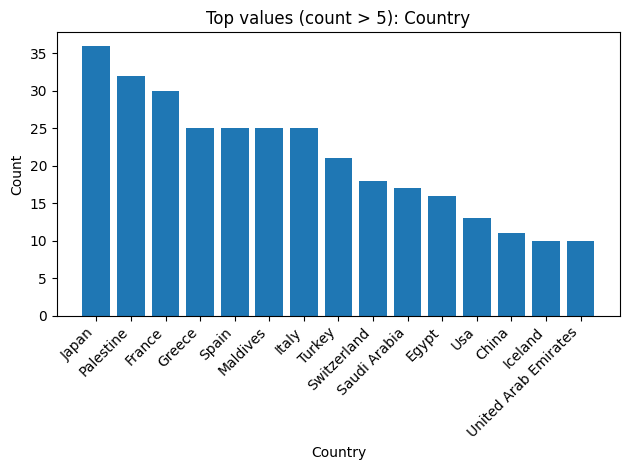

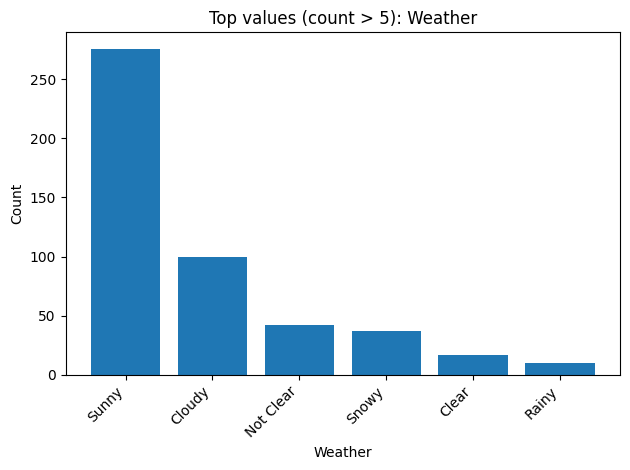

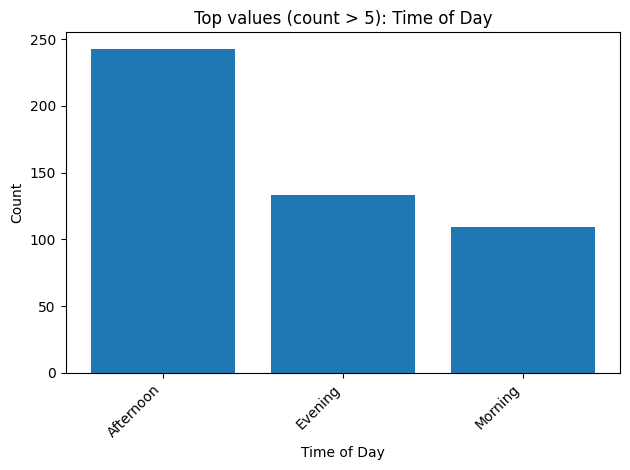

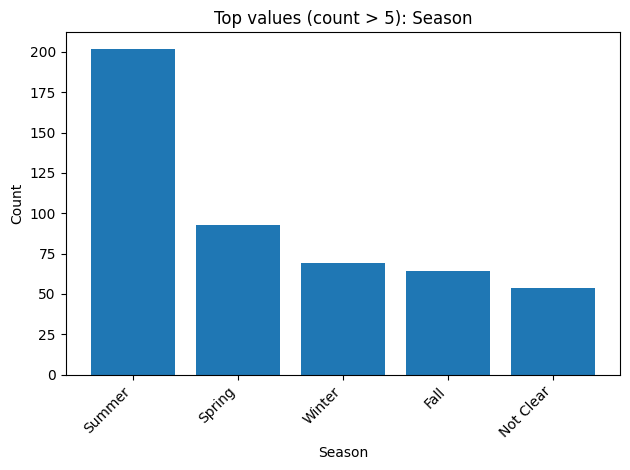

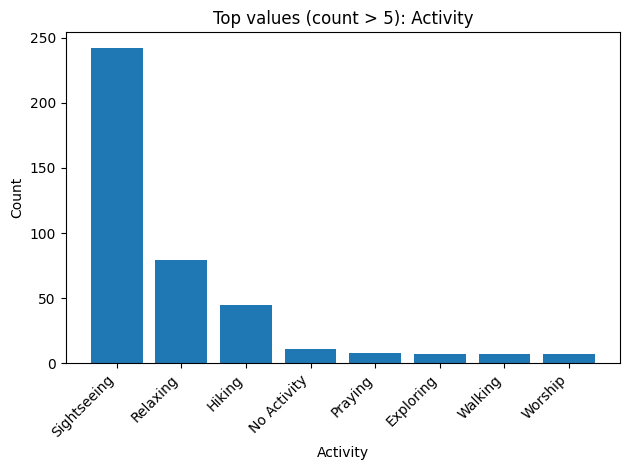

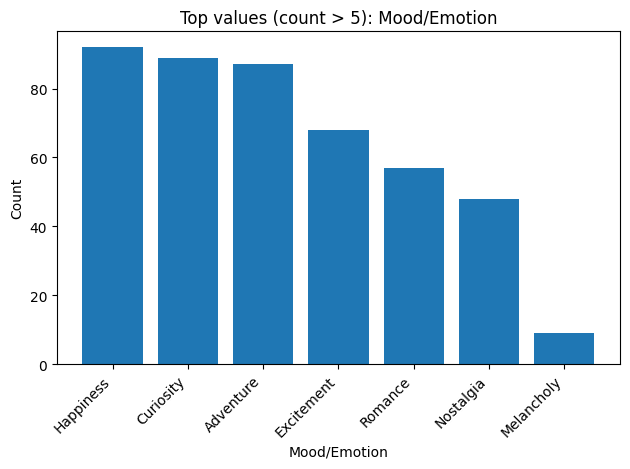


B) Insights: Activity + Time of Day

Activity summary:
  #unique activities: 69
  top activity: Sightseeing ( 242 49.90% )
  rare activities (<5 samples): 60

Time of Day summary:


,time_of_day,count,percent
0,Afternoon,243,50.10
1,Evening,133,27.42
2,Morning,109,22.47



Crosstab counts (Top 15 activities vs Time of Day):


Time of Day,Afternoon,Evening,Morning
Activity,,,
Boat Tour,0,1,1
Boating,2,1,0
Camel Riding,2,2,0
Exploring,5,1,1
Hiking,19,0,26
No Activity,7,3,1
Pilgrimage,3,1,1
Praying,4,2,2
Relaxing,43,18,18



Row % (Time of Day distribution within each Activity) (Top 15):


Time of Day,Afternoon,Evening,Morning
Activity,,,
Boat Tour,0.00,50.00,50.00
Boating,66.67,33.33,0.00
Camel Riding,50.00,50.00,0.00
Exploring,71.43,14.29,14.29
Hiking,42.22,0.00,57.78
No Activity,63.64,27.27,9.09
Pilgrimage,60.00,20.00,20.00
Praying,50.00,25.00,25.00
Relaxing,54.43,22.78,22.78


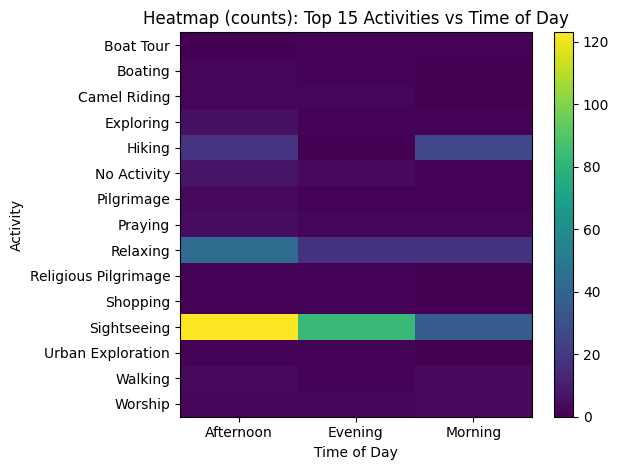

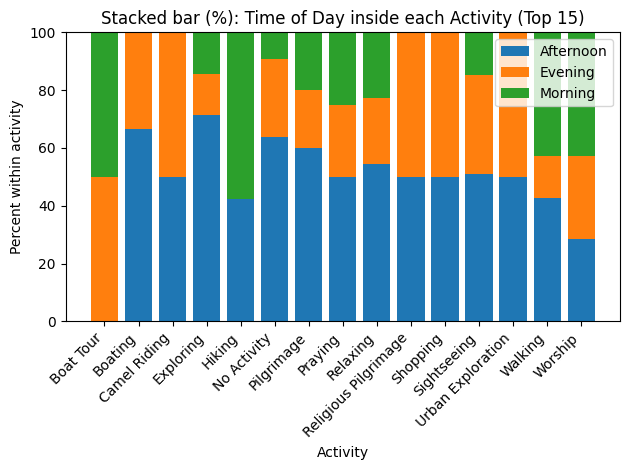


C) Correlations (categorical associations) — Cramér’s V

Cramér’s V matrix (0=weak, 1=strong):


,Country,Weather,Time Of Day,Season,Activity,Mood/Emotion
Country,1.000,0.168,0.241,0.330,0.211,0.000
Weather,0.168,1.000,0.356,0.364,0.000,0.000
Time Of Day,0.241,0.356,1.000,0.245,0.209,0.281
Season,0.330,0.364,0.245,1.000,0.216,0.285
Activity,0.211,0.000,0.209,0.216,1.000,0.327
Mood/Emotion,0.000,0.000,0.281,0.285,0.327,1.000


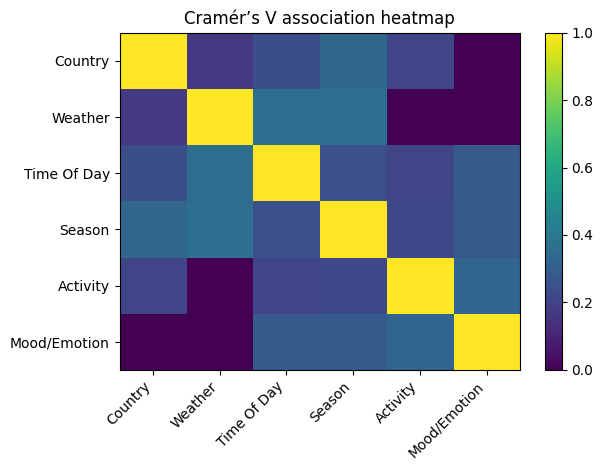

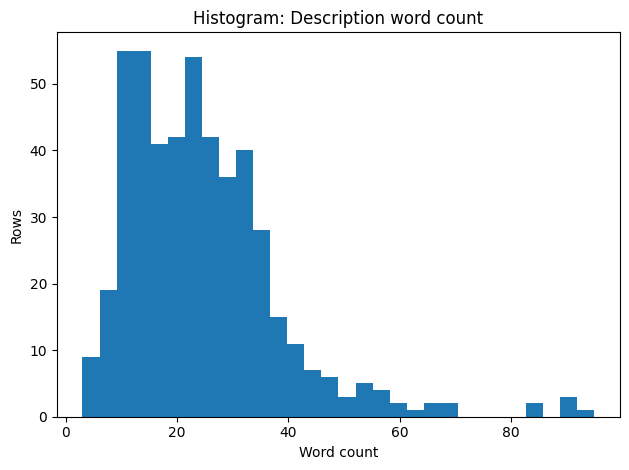

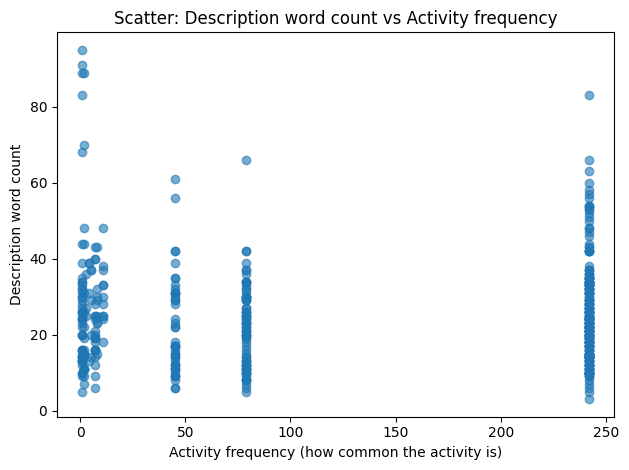

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import chi2_contingency
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# =========================
# CONFIG
# =========================
DATA_PATH = r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset_preprocessed.csv"
SAVE_NORMALIZED = True  # <-- Save normalized labels back to CSV

URL_COL  = "Image URL"
DESC_COL = "Description"
TIME_COL = "Time of Day"
ACT_COL  = "Activity"

# =========================
# 1) LOAD DATA
# =========================
df = pd.read_csv(DATA_PATH)

CAT_COLS = [c for c in ["Country", "Weather", "Time of Day", "Season", "Activity", "Mood/Emotion"] if c in df.columns]

print("Shape:", df.shape)
print("Categorical cols:", CAT_COLS)
display(df.head(3))

# =========================
# 1.5) FORCE BLANK ACTIVITY -> "No Activity"
# =========================
if ACT_COL in df.columns:
    s = df[ACT_COL].fillna("").astype(str).str.strip()
    s_lower = s.str.lower()
    df.loc[s.eq("") | s_lower.eq("nan"), ACT_COL] = "No Activity"

# =========================
# 2) DESCRIPTION WORD COUNT
# =========================
if DESC_COL in dfn.columns:
    wc = dfn[DESC_COL].fillna("").astype(str).str.split().apply(len)
    print("\nDescription word count:")
    print("  avg =", round(wc.mean(), 2), " | min =", int(wc.min()), " | max =", int(wc.max()))
else:
    wc = None

# =========================
# 3) CLASS DISTRIBUTIONS (tables + plots)
# =========================
MIN_COUNT_TO_SHOW = 5
TOP_N = 10

def dist_table(col, top_n=TOP_N, min_count=MIN_COUNT_TO_SHOW):
    vc = dfn[col].value_counts(dropna=False)
    vc = vc[vc > min_count]  # ONLY values with count > threshold
    vc = vc.head(top_n)      # Top N after filtering
    out = pd.DataFrame({
        "value": vc.index,
        "count": vc.values,
        "percent": (vc.values / len(dfn) * 100).round(2)
    })
    return out

print("\n=========================")
print("A) All class distributions (Top values, count >", MIN_COUNT_TO_SHOW, ")")
print("=========================")
for c in CAT_COLS:
    top_tbl = dist_table(c)
    print(f"\nTop values for {c} (case-insensitive):")
    if len(top_tbl) == 0:
        print("  (No values above threshold)")
    else:
        display(top_tbl.assign(value=lambda x: x["value"].astype(str).str.title()))

# Plot distributions
for c in CAT_COLS:
    top_tbl = dist_table(c, top_n=15, min_count=MIN_COUNT_TO_SHOW)
    if len(top_tbl) == 0:
        continue

    labels = [v.title() for v in top_tbl["value"].astype(str).tolist()]
    counts = top_tbl["count"].tolist()

    plt.figure()
    plt.bar(labels, counts)
    plt.title(f"Top values (count > {MIN_COUNT_TO_SHOW}): {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# =========================
# 4) INSIGHTS: Activity & Time of Day
# =========================
print("\n=========================")
print("B) Insights: Activity + Time of Day")
print("=========================")
if ACT_COL in dfn.columns:
    act_vc = dfn[ACT_COL].value_counts()
    print("\nActivity summary:")
    print("  #unique activities:", int(dfn[ACT_COL].nunique()))
    print("  top activity:", act_vc.index[0].title(), "(", act_vc.iloc[0], f"{act_vc.iloc[0]/len(dfn):.2%}", ")")
    print("  rare activities (<5 samples):", int((act_vc < 5).sum()))

if TIME_COL in dfn.columns:
    tod_vc = dfn[TIME_COL].value_counts()
    print("\nTime of Day summary:")
    display(pd.DataFrame({
        "time_of_day": [x.title() for x in tod_vc.index.astype(str)],
        "count": tod_vc.values,
        "percent": (tod_vc.values / len(dfn) * 100).round(2)
    }))

# Crosstab: Activity vs Time of Day
if ACT_COL in dfn.columns and TIME_COL in dfn.columns:
    TOP_ACT = 15
    top_acts = dfn[ACT_COL].value_counts().head(TOP_ACT).index
    sub = dfn[dfn[ACT_COL].isin(top_acts)].copy()

    ct = pd.crosstab(sub[ACT_COL], sub[TIME_COL])
    ct_pct_row = ct.div(ct.sum(axis=1), axis=0) * 100

    print(f"\nCrosstab counts (Top {TOP_ACT} activities vs Time of Day):")
    display(ct.rename(index=str.title, columns=str.title))

    print(f"\nRow % (Time of Day distribution within each Activity) (Top {TOP_ACT}):")
    display(ct_pct_row.round(2).rename(index=str.title, columns=str.title))

    plt.figure()
    plt.imshow(ct.values, aspect="auto")
    plt.colorbar()
    plt.xticks(range(ct.shape[1]), [c.title() for c in ct.columns.astype(str)], rotation=0)
    plt.yticks(range(ct.shape[0]), [r.title() for r in ct.index.astype(str)])
    plt.title(f"Heatmap (counts): Top {TOP_ACT} Activities vs Time of Day")
    plt.xlabel("Time of Day")
    plt.ylabel("Activity")
    plt.tight_layout()
    plt.show()

    labels = [a.title() for a in ct_pct_row.index.astype(str)]
    cols = ct_pct_row.columns.tolist()
    bottom = np.zeros(len(labels))

    plt.figure()
    for c in cols:
        vals = ct_pct_row[c].values
        plt.bar(labels, vals, bottom=bottom, label=str(c).title())
        bottom += vals
    plt.title(f"Stacked bar (%): Time of Day inside each Activity (Top {TOP_ACT})")
    plt.xlabel("Activity")
    plt.ylabel("Percent within activity")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# 5) CORRELATIONS: Cramér’s V
# =========================
print("\n=========================")
print("C) Correlations (categorical associations) — Cramér’s V")
print("=========================")

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    if not SCIPY_OK:
        return np.nan
    tab = pd.crosstab(x, y)
    if tab.size == 0:
        return np.nan
    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = tab.shape
    phi2 = chi2 / n
    if n > 1:
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        denom = min((kcorr-1), (rcorr-1))
        return np.sqrt(phi2corr / denom) if denom > 0 else 0.0
    return 0.0

if len(CAT_COLS) >= 2 and SCIPY_OK:
    V = pd.DataFrame(index=CAT_COLS, columns=CAT_COLS, dtype=float)
    for a in CAT_COLS:
        for b in CAT_COLS:
            V.loc[a, b] = cramers_v(dfn[a], dfn[b])

    print("\nCramér’s V matrix (0=weak, 1=strong):")
    display(V.round(3).rename(index=str.title, columns=str.title))

    plt.figure()
    plt.imshow(V.values, aspect="auto", vmin=0, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(CAT_COLS)), [c.title() for c in CAT_COLS], rotation=45, ha="right")
    plt.yticks(range(len(CAT_COLS)), [c.title() for c in CAT_COLS])
    plt.title("Cramér’s V association heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("SciPy not available OR not enough categorical columns — skipping Cramér’s V.")

# =========================
# 6) VISUALS: Histogram + Scatter (description word count)
# =========================
if wc is not None:
    plt.figure()
    plt.hist(wc.values, bins=30)
    plt.title("Histogram: Description word count")
    plt.xlabel("Word count")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()

    if ACT_COL in dfn.columns:
        act_freq = dfn[ACT_COL].value_counts()
        freq_per_row = dfn[ACT_COL].map(act_freq).astype(int)

        plt.figure()
        plt.scatter(freq_per_row.values, wc.values, alpha=0.6)
        plt.title("Scatter: Description word count vs Activity frequency")
        plt.xlabel("Activity frequency (how common the activity is)")
        plt.ylabel("Description word count")
        plt.tight_layout()
        plt.show()


# Feature extraction & Generating embeddings
a pretrained ResNet-50 model is used to extract high-level visual features from images, transforming each image into a 2048-dimensional feature vector that can be used by K-Nearest Neighbors to predict activity and time-of-day labels.


- Preprocesses images to match ResNet-50 input requirements (resize, normalization).

- Loads a pretrained ResNet-50 model trained on ImageNet.

- Removes the final classification layer to use ResNet-50 as a feature extractor.

- Passes each image through the network in inference mode (no training).

- Extracts a 2048-dimensional feature vector for every image.

- Stores all extracted features in a NumPy array X.

- Extracts corresponding Activity and Time of Day labels from the dataset.

- Prepares image features and labels for use with traditional classifiers (KNN).

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

DATA_CSV = r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\final_complete_dataset_preprocessed.csv"
IMG_DIR  = r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\images_inOrder"

IMG_COL  = "Downloaded_Image_Name"
ACT_COL  = "Activity"
TIME_COL = "Time of Day"

BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

df = pd.read_csv(DATA_CSV)

df = df[df[IMG_COL].notna()].reset_index(drop=True)

print("Dataset size:", len(df))


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

resnet = models.resnet50(pretrained=True)
resnet.fc = nn.Identity()   # remove classifier
resnet = resnet.to(DEVICE)
resnet.eval()

def extract_features(df):
    features = []

    with torch.no_grad():
        for img_name in tqdm(df[IMG_COL], desc="Extracting features"):
            img_path = os.path.join(IMG_DIR, img_name)
            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(DEVICE)

            feat = resnet(img)
            features.append(feat.cpu().numpy().squeeze())

    return np.vstack(features)

X = extract_features(df)
y_activity = df[ACT_COL].values
y_time     = df[TIME_COL].values

print(X.shape)
print(type(X), X.dtype)

Dataset size: 485


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Extracting features: 100%|███████████████████████████████████████████████████████████| 485/485 [06:15<00:00,  1.29it/s]

(485, 2048)
<class 'numpy.ndarray'> float32


# 3. Baseline model
## Model: k-Nearest Neighbors (k-NN) using cosine distance on precomputed image embeddings from ResNet50.

## Tasks:

- Predict Time of Day (3 classes)

- Predict Activity (69 classes, top-10 highlighted in confusion matrices)

## Cross-Validation:

- StratifiedKFold when possible, otherwise KFold (5 folds)

## Metrics (accuracy, macro precision, recall, F1) averaged across folds

### Evaluation:

- Confusion matrices aggregated across folds

- Sample tables show a few actual vs predicted examples per fold

- k Values Tested: k = 1 and k = 3

CV for Time of Day: StratifiedKFold(5)
CV for Activity   : KFold(5)


,task,k,accuracy_mean,accuracy_std,precision_macro_mean,recall_macro_mean,f1_macro_mean,n_samples,n_classes,n_folds
0,Predict Time of Day,1,0.562887,0.057677,0.540442,0.535526,0.537077,485,3,5
1,Predict Time of Day,3,0.546392,0.051028,0.523453,0.490156,0.497036,485,3,5
2,Predict Activity,1,0.457732,0.011754,0.043757,0.048051,0.043672,485,69,5
3,Predict Activity,3,0.486598,0.054259,0.029187,0.034321,0.029491,485,69,5


Saved: D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#3\part3_knn_baseline_cv_results.csv


<Figure size 640x480 with 0 Axes>

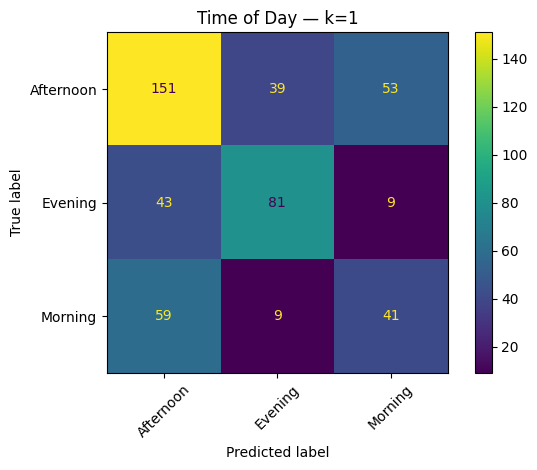

<Figure size 640x480 with 0 Axes>

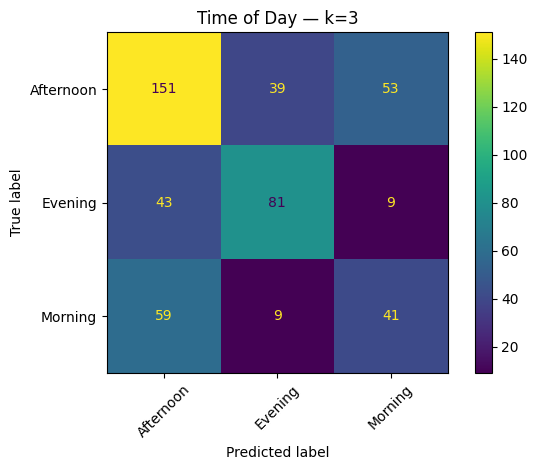

<Figure size 640x480 with 0 Axes>

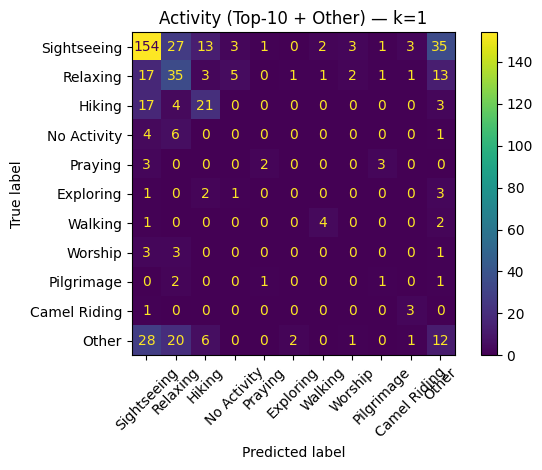

<Figure size 640x480 with 0 Axes>

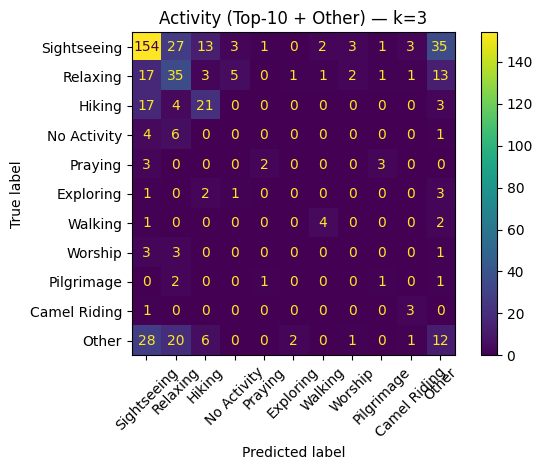


=== Sample Predictions 
 — Time of Day (k=1) ===


,Fold,Actual,Predicted
0,1,afternoon,afternoon
1,1,afternoon,afternoon
2,1,afternoon,evening
3,1,evening,evening
4,1,morning,morning
5,2,morning,afternoon
6,2,evening,evening
7,2,afternoon,afternoon
8,2,afternoon,afternoon
9,2,evening,afternoon



=== Sample Predictions 
 — Activity (k=1) ===


,Fold,Actual,Predicted
0,1,Sightseeing,Sightseeing
1,1,Sightseeing,Sightseeing
2,1,Sightseeing,Walking
3,1,Hiking,Sightseeing / Walking Along The Wall
4,1,Relaxing,Relaxing
5,2,Hiking,Hiking
6,2,Relaxing,Relaxing
7,2,Walking,Walking
8,2,Relaxing,Relaxing
9,2,Sightseeing,Sightseeing



=== Sample Predictions 
 — Time of Day (k=3) ===


,Fold,Actual,Predicted
0,1,afternoon,afternoon
1,1,afternoon,afternoon
2,1,afternoon,evening
3,1,evening,evening
4,1,morning,evening
5,2,morning,afternoon
6,2,evening,evening
7,2,afternoon,morning
8,2,afternoon,morning
9,2,evening,afternoon



=== Sample Predictions 
 — Activity (k=3) ===


,Fold,Actual,Predicted
0,1,Sightseeing,Sightseeing
1,1,Sightseeing,Sightseeing
2,1,Sightseeing,Relaxing
3,1,Hiking,Nature Viewing
4,1,Relaxing,Walking
5,2,Hiking,Hiking
6,2,Relaxing,Relaxing
7,2,Walking,Relaxing
8,2,Relaxing,Sightseeing
9,2,Sightseeing,Sightseeing


In [52]:
# ============================================================
# k-NN Baseline with Precomputed Embeddings, CV, and Sample Tables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import StratifiedKFold, KFold

# ------------------------------------------------------------
#  EXIST (from previous cells)
# ------------------------------------------------------------
# X      : numpy array of embeddings (n_samples, embedding_dim)
# df  : dataframe aligned with X, columns: ["Time of Day", "Activity"]

TIME_COL = "Time of Day"
ACT_COL  = "Activity"

# ------------------------------------------------------------
# 1) CV splits
# ------------------------------------------------------------
def make_splits(y, max_folds=5, seed=42, prefer_strat=True):
    y = np.asarray(y)
    n = len(y)
    max_folds = min(max_folds, n)

    if prefer_strat:
        vc = pd.Series(y).value_counts()
        min_count = int(vc.min())
        if min_count >= 2:
            n_splits = min(max_folds, min_count)
            if n_splits >= 2:
                skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
                return list(skf.split(np.zeros(n), y)), f"StratifiedKFold({n_splits})"

    kf = KFold(n_splits=max_folds, shuffle=True, random_state=seed)
    return list(kf.split(np.zeros(n))), f"KFold({max_folds})"

time_splits, time_cv_name = make_splits(df[TIME_COL].values)
act_splits, act_cv_name   = make_splits(df[ACT_COL].values)

print("CV for Time of Day:", time_cv_name)
print("CV for Activity   :", act_cv_name)

# ------------------------------------------------------------
# 2) Confusion matrix label handling
# ------------------------------------------------------------
labels_time_cm = sorted(df[TIME_COL].unique())

top10_acts = df[ACT_COL].value_counts().head(10).index.tolist()
labels_act_cm = top10_acts + ["other"]

def map_activity_cm(arr):
    return np.array([v if v in top10_acts else "other" for v in arr], dtype=object)

# ------------------------------------------------------------
# 3) CV evaluation for k-NN with sample tables
# ------------------------------------------------------------
def run_cv_knn_with_samples(
    X, y, splits, task_name,
    k_values=(1, 3),
    labels_for_macro=None,
    cm_labels=None,
    cm_map=None,
    display_samples=5
):
    y = np.asarray(y)
    rows = []
    cm_by_k = {}
    samples_by_k = {}

    for k in k_values:
        fold_acc, fold_p, fold_r, fold_f1 = [], [], [], []
        cm_sum = np.zeros((len(cm_labels), len(cm_labels)), dtype=int) if cm_labels is not None else None
        fold_samples = []

        for fold_idx, (tr, te) in enumerate(splits):
            clf = KNeighborsClassifier(n_neighbors=k, metric="cosine", algorithm="brute")
            clf.fit(X[tr], y[tr])
            pred = clf.predict(X[te])

            # Metrics
            acc = accuracy_score(y[te], pred)
            p, r, f1, _ = precision_recall_fscore_support(
                y[te], pred,
                labels=labels_for_macro,
                average="macro",
                zero_division=0
            )

            fold_acc.append(acc)
            fold_p.append(p)
            fold_r.append(r)
            fold_f1.append(f1)

            # Confusion matrix
            if cm_labels is not None:
                y_te_cm = cm_map(y[te]) if cm_map else y[te]
                pred_cm = cm_map(pred)  if cm_map else pred
                cm_sum += confusion_matrix(y_te_cm, pred_cm, labels=cm_labels)

            # Sample table for actual vs predicted
            n_disp = min(display_samples, len(te))
            fold_samples.append(pd.DataFrame({
                "Fold": fold_idx + 1,
                "Actual": y[te][:n_disp],
                "Predicted": pred[:n_disp]
            }))

        rows.append({
            "task": task_name,
            "k": k,
            "accuracy_mean": np.mean(fold_acc),
            "accuracy_std":  np.std(fold_acc, ddof=1),
            "precision_macro_mean": np.mean(fold_p),
            "recall_macro_mean":    np.mean(fold_r),
            "f1_macro_mean":        np.mean(fold_f1),
            "n_samples": len(y),
            "n_classes": len(np.unique(y)),
            "n_folds": len(splits)
        })

        cm_by_k[k] = cm_sum
        samples_by_k[k] = pd.concat(fold_samples).reset_index(drop=True)

    return pd.DataFrame(rows), cm_by_k, samples_by_k

# ------------------------------------------------------------
# Run k-NN
# ------------------------------------------------------------
time_labels_macro = sorted(df[TIME_COL].unique())
act_labels_macro  = sorted(df[ACT_COL].unique())

time_results, time_cm, time_samples = run_cv_knn_with_samples(
    X, df[TIME_COL].values, time_splits,
    "Predict Time of Day",
    labels_for_macro=time_labels_macro,
    cm_labels=labels_time_cm,
    display_samples=5
)

act_results, act_cm, act_samples = run_cv_knn_with_samples(
    X, df[ACT_COL].values, act_splits,
    "Predict Activity",
    labels_for_macro=act_labels_macro,
    cm_labels=labels_act_cm,
    cm_map=map_activity_cm,
    display_samples=5
)

results_df = pd.concat([time_results, act_results], ignore_index=True)
display(results_df)

OUT = Path("part3_knn_baseline_cv_results.csv")
results_df.to_csv(OUT, index=False)
print("Saved:", OUT.resolve())

# ------------------------------------------------------------
# 4) Plot confusion matrices
# ------------------------------------------------------------
def plot_cm(cm, labels, title):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[str(l).title() for l in labels]
    )
    plt.figure()
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cm(time_cm[1], labels_time_cm, "Time of Day — k=1")
plot_cm(time_cm[1], labels_time_cm, "Time of Day — k=3")
plot_cm(act_cm[1], labels_act_cm, "Activity (Top-10 + Other) — k=1")
plot_cm(act_cm[1], labels_act_cm, "Activity (Top-10 + Other) — k=3")

# ------------------------------------------------------------
# 5) Display sample tables for actual vs predicted
# ------------------------------------------------------------
def display_samples_table(samples_dict, k):
    df_samples = samples_dict[k]
    # Optional: color highlighting
    def highlight_fold(row):
        colors = ["#fff0f5", "#ffe4e1", "#ffe4b5", "#fafad2", "#e0ffff"]
        return [f"background-color: {colors[(row['Fold']-1)%len(colors)]}"] * len(row)

    styled = df_samples.style.apply(highlight_fold, axis=1)
    display(styled)

print("\n=== Sample Predictions \n — Time of Day (k=1) ===")
display_samples_table(time_samples, 1)

print("\n=== Sample Predictions \n — Activity (k=1) ===")
display_samples_table(act_samples, 1)

print("\n=== Sample Predictions \n — Time of Day (k=3) ===")
display_samples_table(time_samples, 3)

print("\n=== Sample Predictions \n — Activity (k=3) ===")
display_samples_table(act_samples, 3)


## Results Interpretation

### Time of Day:

- k=1 accuracy ≈ 56%, k=3 ≈ 55%

- Macro precision/recall/F1 ≈ 53–54%

- Indicates moderate ability to distinguish between morning, afternoon, and evening from embeddings.

### Activity:

- k=1 accuracy ≈ 46%, k=3 ≈ 49%

- Macro metrics are very low (≈ 3–5%) due to large class imbalance and many rare activity classes.

- Top-10 classes are easier to predict, but overall many classes are poorly predicted.

### Overall insights:

- k-NN provides a simple baseline for both tasks.

- Works better for coarse-grained tasks (Time of Day) than fine-grained, highly imbalanced tasks (Activity).

Sample tables help qualitatively check which predictions are correct and where the model fails.

## 4.1. Random forest

### Model: Random Forest Classifier (scikit-learn)

### Cross-Validation:

- Time of Day: Stratified K-Fold (5 splits) to preserve class distribution.

- Activity: Stratified K-Fold after collapsing rare classes to “other” to stabilize evaluation.

### Hyperparameter Sweep: Tested n_estimators = [50, 100, 200, 400, 600].

### Evaluation:

- Out-of-Fold (OOF) predictions used for robust cross-validated metrics.

- Metrics: accuracy, macro-precision, macro-recall, macro-F1.

- Top-K activity mapping (optional) for reporting and visualization. - ### remove? ####-

- Sample inspection: Random selection of OOF predictions to inspect actual vs. predicted labels

In [9]:
# ============================================================
# Random Forest (Stratified K-Fold + OOF + Top-K Activity)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -------------------------------
# Configuration
# -------------------------------

n_estimators_list = [50, 100, 200, 400, 600]
N_SPLITS = 5
RANDOM_STATE = 42
DISPLAY_SAMPLES = 10  # total OOF samples to display
TOP_K_ACT = 10        # Top-K activities for simplified task

# Assumed already defined:
# X           -> embeddings (N, D)
# y_time      -> Time of Day labels
# y_activity  -> Activity labels

# -------------------------------
# Collapse rare activity classes for robust evaluation
# -------------------------------

def collapse_rare_classes(y, min_count):
    y = pd.Series(y).astype(str)
    vc = y.value_counts()
    rare_classes = vc[vc < min_count].index
    y[y.isin(rare_classes)] = "other"
    return y.values

y_activity_clean = collapse_rare_classes(y_activity, min_count=N_SPLITS)

# -------------------------------
# Top-K activity mapping (optional simplified visualization)
# -------------------------------

top_k_activities = pd.Series(y_activity).value_counts().head(TOP_K_ACT).index.tolist()
y_activity_topk = np.array([a if a in top_k_activities else "other" for a in y_activity], dtype=object)

print("Top-K activities:", top_k_activities)
print("Class distribution after Top-K mapping:")
print(pd.Series(y_activity_topk).value_counts())

# -------------------------------
# Stratified K-Fold
# -------------------------------

time_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
act_cv  = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# -------------------------------
# OOF Random Forest evaluation
# -------------------------------

def rf_stratified_oof(X, y, splits, n_estimators):
    oof_pred = np.empty(len(y), dtype=object)
    fold_id  = np.empty(len(y), dtype=int)

    acc_list, prec_list, rec_list, f1_list = [], [], [], []

    for fold, (tr, te) in enumerate(splits, start=1):
        clf = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        oof_pred[te] = pred
        fold_id[te] = fold

        acc = accuracy_score(y[te], pred)
        p, r, f1, _ = precision_recall_fscore_support(y[te], pred, average="macro", zero_division=0)
        acc_list.append(acc)
        prec_list.append(p)
        rec_list.append(r)
        f1_list.append(f1)

    metrics = {
        "avg_accuracy": np.mean(acc_list),
        "avg_precision": np.mean(prec_list),
        "avg_recall": np.mean(rec_list),
        "avg_f1": np.mean(f1_list)
    }

    return oof_pred, fold_id, metrics

# -------------------------------
# Run hyperparameter sweep
# -------------------------------

metrics_rows = []
samples_rows = []

for n in n_estimators_list:
    print(f"\nRunning Random Forest | n_estimators = {n}")

    # ---- Time of Day ----
    oof_time, fold_time, time_metrics = rf_stratified_oof(
        X, y_time, time_cv.split(X, y_time), n_estimators=n
    )
    metrics_rows.append({
        "task": "Time of Day",
        "n_estimators": n,
        **time_metrics
    })
    samples_rows.append(pd.DataFrame({
        "task": "Time of Day",
        "n_estimators": n,
        "Fold": fold_time,
        "Actual": y_time,
        "Predicted": oof_time
    }))

    # ---- Activity (collapsed rare classes) ----
    oof_act, fold_act, act_metrics = rf_stratified_oof(
        X, y_activity_clean, act_cv.split(X, y_activity_clean), n_estimators=n
    )
    metrics_rows.append({
        "task": "Activity",
        "n_estimators": n,
        **act_metrics
    })
    samples_rows.append(pd.DataFrame({
        "task": "Activity",
        "n_estimators": n,
        "Fold": fold_act,
        "Actual": y_activity_clean,
        "Predicted": oof_act
    }))

# -------------------------------
# Metrics table
# -------------------------------

metrics_df = pd.DataFrame(metrics_rows)
print("\n=== Cross-Validated Metrics ===")
display(metrics_df)

# -------------------------------
# Random OOF test samples for inspection
# -------------------------------

samples_df = pd.concat(samples_rows, ignore_index=True)
random_oof_samples = samples_df.sample(
    n=min(DISPLAY_SAMPLES, len(samples_df)),
    random_state=RANDOM_STATE
)

print("\n=== Random OOF Test Predictions ===")
display(random_oof_samples)

# -------------------------------
# Optional: Top-K Activity evaluation table for reporting
# -------------------------------

act_topk_metrics = []
for n in n_estimators_list:
    oof_topk, _, metrics_topk = rf_stratified_oof(
        X, y_activity_topk, act_cv.split(X, y_activity_topk), n_estimators=n
    )
    act_topk_metrics.append({
        "n_estimators": n,
        **metrics_topk
    })

act_topk_df = pd.DataFrame(act_topk_metrics)
print("\n=== Top-K Activity Metrics ===")
display(act_topk_df)


Top-K activities: ['Sightseeing', 'Relaxing', 'Hiking', 'No Activity', 'Praying', 'Exploring', 'Walking', 'Worship', 'Pilgrimage', 'Camel Riding']
Class distribution after Top-K mapping:
Sightseeing     242
Relaxing         79
other            70
Hiking           45
No Activity      11
Praying           8
Walking           7
Worship           7
Exploring         7
Pilgrimage        5
Camel Riding      4
Name: count, dtype: int64

Running Random Forest | n_estimators = 50

Running Random Forest | n_estimators = 100

Running Random Forest | n_estimators = 200

Running Random Forest | n_estimators = 400

Running Random Forest | n_estimators = 600

=== Cross-Validated Metrics ===


,task,n_estimators,avg_accuracy,avg_precision,avg_recall,avg_f1
0,Time of Day,50,0.639175,0.673209,0.544371,0.549915
1,Activity,50,0.564948,0.299380,0.254883,0.253889
2,Time of Day,100,0.639175,0.665775,0.538157,0.540008
3,Activity,100,0.575258,0.303140,0.257747,0.256700
4,Time of Day,200,0.632990,0.662879,0.530948,0.534304
5,Activity,200,0.579381,0.323451,0.258655,0.257433
6,Time of Day,400,0.639175,0.698325,0.532146,0.536143
7,Activity,400,0.581443,0.327953,0.262591,0.262804
8,Time of Day,600,0.645361,0.711973,0.534054,0.535339
9,Activity,600,0.589691,0.333318,0.266896,0.268128



=== Random OOF Test Predictions ===


,task,n_estimators,Fold,Actual,Predicted
3881,Time of Day,600,5,evening,evening
1684,Activity,100,1,Sightseeing,Sightseeing
1044,Time of Day,100,3,evening,evening
4810,Activity,600,3,Sightseeing,Sightseeing
1538,Activity,100,3,Sightseeing,Sightseeing
1034,Time of Day,100,3,afternoon,afternoon
2107,Time of Day,200,1,evening,afternoon
4261,Time of Day,600,1,morning,afternoon
4026,Time of Day,600,1,afternoon,afternoon
4063,Time of Day,600,4,afternoon,afternoon


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:80


=== Top-K Activity Metrics ===


,n_estimators,avg_accuracy,avg_precision,avg_recall,avg_f1
0,50,0.579381,0.288862,0.246247,0.245957
1,100,0.583505,0.303262,0.247099,0.245861
2,200,0.585567,0.290235,0.244909,0.243738
3,400,0.600000,0.302539,0.250725,0.250839
4,600,0.593814,0.300033,0.247126,0.246951


## Results interpetaion:

### Time of Day Prediction:

- Accuracy: ~0.645 (best at 600 trees)

- Macro-Precision: 0.712

- Macro-Recall: 0.534

- Macro-F1: 0.535

Reasonable performance for a 3-class classification task.

### Activity Prediction:

- Accuracy: ~0.590 (best at 600 trees)

- Macro-Precision: 0.333

- Macro-Recall: 0.267

- Macro-F1: 0.268

Lower metrics due to high class imbalance and many activity classes (69 classes).

### Trend Observed:

- Increasing n_estimators slightly improves performance for both tasks.

Macro-precision benefits more than recall/F1 for imbalanced activity prediction
The Random Forest model was trained to predict Time of Day and Activity using 5-fold Stratified Cross-Validation and a hyperparameter sweep over n_estimators ranging from 50 to 600. For Time of Day, the model achieved the best performance with an accuracy of 0.645 and macro-F1 of 0.535, showing consistent improvement with increasing estimators. However, for Activity, performance was significantly lower, with an accuracy of 0.590 and a macro-F1 of 0.268, likely due to the high class imbalance and a large number of activity classes. The model demonstrates good applicability for time-based predictions but struggles with multi-class activity recognition due to class imbalance.

# 4.2. Convolutional Neural Network

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_encoded)

# ============================================================
# Train / Validation Split
# ============================================================

X_train, X_val, y_time_train, y_time_val, y_activity_train, y_activity_val = train_test_split(
    X, y_time_onehot, y_activity_onehot, test_size=0.2, random_state=42
)

# ============================================================
# Build Multi-Output CNN Model
# ============================================================

input_layer = layers.Input(shape=(X.shape[1], 1))  # Conv1D expects 3D input
x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Outputs
time_output = layers.Dense(y_time_onehot.shape[1], activation='softmax', name='time_output')(x)
activity_output = layers.Dense(y_activity_onehot.shape[1], activation='softmax', name='activity_output')(x)

cnn_model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
cnn_model.compile(
    optimizer='adam',
    loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
    metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
)

# ============================================================
# Reshape X for Conv1D
# ============================================================

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]

# ============================================================
# Train the Model
# ============================================================

history = cnn_model.fit(
    X_train_cnn,
    {'time_output': y_time_train, 'activity_output': y_activity_train},
    validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
    epochs=20,
    batch_size=32
)

# ============================================================
# Predict on Validation Set
# ============================================================

preds = cnn_model.predict(X_val_cnn)
time_pred = preds[0].argmax(axis=1)
activity_pred = preds[1].argmax(axis=1)

time_actual = y_time_val.argmax(axis=1)
activity_actual = y_activity_val.argmax(axis=1)

# ============================================================
# Compute Precision, Recall, F1
# ============================================================

time_precision = precision_score(time_actual, time_pred, average='macro', zero_division=0)
time_recall = recall_score(time_actual, time_pred, average='macro', zero_division=0)
time_f1 = f1_score(time_actual, time_pred, average='macro', zero_division=0)

activity_precision = precision_score(activity_actual, activity_pred, average='macro', zero_division=0)
activity_recall = recall_score(activity_actual, activity_pred, average='macro', zero_division=0)
activity_f1 = f1_score(activity_actual, activity_pred, average='macro', zero_division=0)

print("\n=== Metrics ===")
print(f"Time of Day | Precision: {time_precision:.4f}, Recall: {time_recall:.4f}, F1: {time_f1:.4f}")
print(f"Activity    | Precision: {activity_precision:.4f}, Recall: {activity_recall:.4f}, F1: {activity_f1:.4f}")

# ============================================================
# Actual vs Predicted Table (as strings)
# ============================================================

time_actual_str = time_encoder.inverse_transform(time_actual)
time_pred_str = time_encoder.inverse_transform(time_pred)
activity_actual_str = activity_encoder.inverse_transform(activity_actual)
activity_pred_str = activity_encoder.inverse_transform(activity_pred)

samples_df = pd.DataFrame({
    'Actual Time of Day': time_actual_str.astype(str),
    'Predicted Time of Day': time_pred_str.astype(str),
    'Actual Activity': activity_actual_str.astype(str),
    'Predicted Activity': activity_pred_str.astype(str)
})

# Display 10 random samples
random_samples = samples_df.sample(n=10, random_state=42)
print("\n=== Random Actual vs Predicted Samples ===")
display(random_samples)


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 659ms/step - activity_output_accuracy: 0.3969 - activity_output_loss: 4.4619 - loss: 7.1646 - time_output_accuracy: 0.3969 - time_output_loss: 2.6018 - val_activity_output_accuracy: 0.4742 - val_activity_output_loss: 3.4438 - val_loss: 4.3014 - val_time_output_accuracy: 0.6495 - val_time_output_loss: 0.8711
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 546ms/step - activity_output_accuracy: 0.5077 - activity_output_loss: 2.7884 - loss: 3.7836 - time_output_accuracy: 0.5129 - time_output_loss: 0.9839 - val_activity_output_accuracy: 0.4742 - val_activity_output_loss: 2.3132 - val_loss: 3.4343 - val_time_output_accuracy: 0.5670 - val_time_output_loss: 0.7654
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 547ms/step - activity_output_accuracy: 0.5309 - activity_output_loss: 1.9749 - loss: 2.8346 - time_output_accuracy: 0.6134 - time_output_loss: 0.8903 - val_activity_output_accuracy: 0.4948 - val_activity_output_loss: 2.3809 - val_loss: 3.4051 - val_time_outp

,Actual Time of Day,Predicted Time of Day,Actual Activity,Predicted Activity
62,afternoon,afternoon,Hiking,Hiking
40,morning,morning,Relaxing,Relaxing
93,afternoon,afternoon,Boat Riding,Sightseeing
18,evening,afternoon,Sightseeing,Sightseeing
81,afternoon,evening,Sightseeing,Relaxing
83,afternoon,evening,Walking / City Exploring,Relaxing
64,evening,evening,Religious Pilgrimage,Sightseeing
42,afternoon,afternoon,Sightseeing,No Activity
10,afternoon,afternoon,Sightseeing,Sightseeing
0,morning,afternoon,Sightseeing,Hiking


### class weights included

In [11]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# Encode Labels
# ============================================================

time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_encoded)

# ============================================================
# Train/Validation Split
# ============================================================

X_train, X_val, y_time_train, y_time_val, y_activity_train, y_activity_val = train_test_split(
    X, y_time_onehot, y_activity_onehot, test_size=0.2, random_state=42, shuffle=True
)

# ============================================================
# Convert One-Hot → Class Labels
# ============================================================

y_time_train_lbl = y_time_train.argmax(axis=1)
y_activity_train_lbl = y_activity_train.argmax(axis=1)

num_time_classes = y_time_onehot.shape[1]  # 3
num_activity_classes = y_activity_onehot.shape[1]  # 68

# ============================================================
# Compute Class Weights (fill missing classes with 1.0)
# ============================================================

def full_class_weights(labels, num_classes):
    present_classes = np.unique(labels)
    weights = np.ones(num_classes, dtype=np.float32)
    cw = compute_class_weight("balanced", classes=present_classes, y=labels)
    for cls, w in zip(present_classes, cw):
        weights[cls] = w
    return weights

time_class_weights = full_class_weights(y_time_train_lbl, num_time_classes)
activity_class_weights = full_class_weights(y_activity_train_lbl, num_activity_classes)

# ============================================================
# Weighted Loss Functions
# ============================================================

def weighted_categorical_crossentropy(weights):
    weights = tf.constant(weights, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        y_true_labels = tf.argmax(y_true, axis=-1)
        weights_vec = tf.gather(weights, y_true_labels)
        loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights_vec)
    return loss_fn

time_loss = weighted_categorical_crossentropy(time_class_weights)
activity_loss = weighted_categorical_crossentropy(activity_class_weights)

# ============================================================
# Build Multi-Output CNN
# ============================================================

input_layer = layers.Input(shape=(X.shape[1], 1))
x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

time_output = layers.Dense(num_time_classes, activation='softmax', name='time_output')(x)
activity_output = layers.Dense(num_activity_classes, activation='softmax', name='activity_output')(x)

cnn_model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
cnn_model.compile(
    optimizer='adam',
    loss={'time_output': time_loss, 'activity_output': activity_loss},
    metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
)

# ============================================================
# Reshape X for Conv1D
# ============================================================

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]

# ============================================================
# Train Model
# ============================================================

history = cnn_model.fit(
    X_train_cnn,
    {'time_output': y_time_train, 'activity_output': y_activity_train},
    validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
    epochs=20,
    batch_size=32,
    verbose=1
)

# ============================================================
# Predict
# ============================================================

time_pred, activity_pred = cnn_model.predict(X_val_cnn)
time_pred_lbl = time_pred.argmax(axis=1)
activity_pred_lbl = activity_pred.argmax(axis=1)
time_actual_lbl = y_time_val.argmax(axis=1)
activity_actual_lbl = y_activity_val.argmax(axis=1)

# ============================================================
# Metrics
# ============================================================

time_precision = precision_score(time_actual_lbl, time_pred_lbl, average='macro', zero_division=0)
time_recall = recall_score(time_actual_lbl, time_pred_lbl, average='macro', zero_division=0)
time_f1 = f1_score(time_actual_lbl, time_pred_lbl, average='macro', zero_division=0)

activity_precision = precision_score(activity_actual_lbl, activity_pred_lbl, average='macro', zero_division=0)
activity_recall = recall_score(activity_actual_lbl, activity_pred_lbl, average='macro', zero_division=0)
activity_f1 = f1_score(activity_actual_lbl, activity_pred_lbl, average='macro', zero_division=0)

print("\n=== Macro Metrics ===")
print(f"Time of Day | Precision: {time_precision:.4f}, Recall: {time_recall:.4f}, F1: {time_f1:.4f}")
print(f"Activity    | Precision: {activity_precision:.4f}, Recall: {activity_recall:.4f}, F1: {activity_f1:.4f}")

# ============================================================
# Actual vs Predicted Samples
# ============================================================

samples_df = pd.DataFrame({
    "Actual Time of Day": time_encoder.inverse_transform(time_actual_lbl).astype(str),
    "Predicted Time of Day": time_encoder.inverse_transform(time_pred_lbl).astype(str),
    "Actual Activity": activity_encoder.inverse_transform(activity_actual_lbl).astype(str),
    "Predicted Activity": activity_encoder.inverse_transform(activity_pred_lbl).astype(str)
})

print("\n=== Random Actual vs Predicted Samples ===")
display(samples_df.sample(10, random_state=42))


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 631ms/step - activity_output_accuracy: 0.0232 - activity_output_loss: 5.9829 - loss: 8.8777 - time_output_accuracy: 0.3222 - time_output_loss: 2.4036 - val_activity_output_accuracy: 0.0000e+00 - val_activity_output_loss: 2.2490 - val_loss: 3.8695 - val_time_output_accuracy: 0.4845 - val_time_output_loss: 0.9627
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 653ms/step - activity_output_accuracy: 0.0180 - activity_output_loss: 3.8856 - loss: 5.2187 - time_output_accuracy: 0.4897 - time_output_loss: 1.0697 - val_activity_output_accuracy: 0.0206 - val_activity_output_loss: 2.2714 - val_loss: 3.8856 - val_time_output_accuracy: 0.6082 - val_time_output_loss: 0.9601
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 591ms/step - activity_output_accuracy: 0.0490 - activity_output_loss: 3.9426 - loss: 5.0573 - time_output_accuracy: 0.5722 - time_output_loss: 1.0595 - val_activity_output_accuracy: 0.0206 - val_activity_output_loss: 2.2618 - val_loss: 3.8196 - val_time_

,Actual Time of Day,Predicted Time of Day,Actual Activity,Predicted Activity
62,afternoon,morning,Hiking,Hiking
40,morning,morning,Relaxing,Relaxing
93,afternoon,afternoon,Boat Riding,Boat Riding / Swimming / Sightseeing
18,evening,afternoon,Sightseeing,Sightseeing
81,afternoon,evening,Sightseeing,Relaxing
83,afternoon,evening,Walking / City Exploring,Boarding
64,evening,evening,Religious Pilgrimage,Worship
42,afternoon,evening,Sightseeing,No Activity
10,afternoon,afternoon,Sightseeing,Worship
0,morning,morning,Sightseeing,Hiking


In [17]:
###### from here
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_encoded)

# ============================================================
# K-Fold Cross-Validation Setup
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

time_accuracies = []
time_precisions = []
time_recalls = []
time_f1s = []

activity_accuracies = []
activity_precisions = []
activity_recalls = []
activity_f1s = []

fold = 1
for train_idx, val_idx in kf.split(X):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    time_output = layers.Dense(y_time_onehot.shape[1], activation='softmax', name='time_output')(x)
    activity_output = layers.Dense(y_activity_onehot.shape[1], activation='softmax', name='activity_output')(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # reduce for speed, increase if needed
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")



=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 579ms/step - activity_output_accuracy: 0.2835 - activity_output_loss: 4.5154 - loss: 6.8943 - time_output_accuracy: 0.4304 - time_output_loss: 2.2127 - val_activity_output_accuracy: 0.4742 - val_activity_output_loss: 2.3468 - val_loss: 3.8248 - val_time_output_accuracy: 0.3608 - val_time_output_loss: 1.1878
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 535ms/step - activity_output_accuracy: 0.4974 - activity_output_loss: 2.3775 - loss: 3.4470 - time_output_accuracy: 0.4485 - time_output_loss: 1.0576 - val_activity_output_accuracy: 0.4742 - val_activity_output_loss: 2.1516 - val_loss: 3.4752 - val_time_output_accuracy: 0.5567 - val_time_output_loss: 0.8365
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 539ms/step - activity_output_accuracy: 0.5464 - activity_output_loss: 2.2214 - loss: 2.9577 - time_output_accuracy: 0.5851 - time_output_loss: 0.9067 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 2.3062 - val_loss: 3.4046

In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

# Define threshold for rare classes (e.g., less than 5% of samples)
rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

# Combine rare classes into a new "other" class
y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

# One-hot encode the combined activity labels
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    time_output = layers.Dense(y_time_onehot.shape[1], activation='softmax', name='time_output')(x)
    activity_output = layers.Dense(num_activity_classes, activation='softmax', name='activity_output')(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for real training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 596ms/step - activity_output_accuracy: 0.3505 - activity_output_loss: 3.4109 - loss: 6.4251 - time_output_accuracy: 0.3325 - time_output_loss: 2.8359 - val_activity_output_accuracy: 0.3505 - val_activity_output_loss: 2.0343 - val_loss: 3.1438 - val_time_output_accuracy: 0.5670 - val_time_output_loss: 0.8668
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 569ms/step - activity_output_accuracy: 0.4742 - activity_output_loss: 1.5271 - loss: 2.5150 - time_output_accuracy: 0.5284 - time_output_loss: 1.0095 - val_activity_output_accuracy: 0.5258 - val_activity_output_loss: 0.9847 - val_loss: 2.0162 - val_time_outp

In [20]:
# increase dropuout to 0.5
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

# Define threshold for rare classes (e.g., less than 5% of samples)
rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

# Combine rare classes into a new "other" class
y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

# One-hot encode the combined activity labels
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    time_output = layers.Dense(y_time_onehot.shape[1], activation='softmax', name='time_output')(x)
    activity_output = layers.Dense(num_activity_classes, activation='softmax', name='activity_output')(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for real training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 748ms/step - activity_output_accuracy: 0.3892 - activity_output_loss: 2.4366 - loss: 5.8717 - time_output_accuracy: 0.4407 - time_output_loss: 3.2868 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 2.2083 - val_loss: 2.9563 - val_time_output_accuracy: 0.5567 - val_time_output_loss: 0.8149
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 631ms/step - activity_output_accuracy: 0.4897 - activity_output_loss: 1.8572 - loss: 2.8572 - time_output_accuracy: 0.5232 - time_output_loss: 1.0189 - val_activity_output_accuracy: 0.4536 - val_activity_output_loss: 1.1939 - val_loss: 2.1743 - val_time_outp

In [22]:
# increase dropuout to 0.7
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

# Define threshold for rare classes (e.g., less than 5% of samples)
rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

# Combine rare classes into a new "other" class
y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

# One-hot encode the combined activity labels
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.7)(x)

    time_output = layers.Dense(y_time_onehot.shape[1], activation='softmax', name='time_output')(x)
    activity_output = layers.Dense(num_activity_classes, activation='softmax', name='activity_output')(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for real training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 575ms/step - activity_output_accuracy: 0.2938 - activity_output_loss: 3.4985 - loss: 6.1406 - time_output_accuracy: 0.4098 - time_output_loss: 2.4351 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 2.5430 - val_loss: 3.4234 - val_time_output_accuracy: 0.5361 - val_time_output_loss: 0.9380
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 629ms/step - activity_output_accuracy: 0.4820 - activity_output_loss: 2.0872 - loss: 3.3617 - time_output_accuracy: 0.4227 - time_output_loss: 1.2137 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 1.4980 - val_loss: 2.4413 - val_time_outp

In [23]:
# reduce dense layer to 128
# increase dropuout to 0.7
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

# Define threshold for rare classes (e.g., less than 5% of samples)
rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

# Combine rare classes into a new "other" class
y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

# One-hot encode the combined activity labels
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.7)(x)

    time_output = layers.Dense(y_time_onehot.shape[1], activation='softmax', name='time_output')(x)
    activity_output = layers.Dense(num_activity_classes, activation='softmax', name='activity_output')(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for real training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 526ms/step - activity_output_accuracy: 0.2474 - activity_output_loss: 3.5091 - loss: 6.3006 - time_output_accuracy: 0.3686 - time_output_loss: 2.6405 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 3.1157 - val_loss: 4.1214 - val_time_output_accuracy: 0.5361 - val_time_output_loss: 1.0176
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - activity_output_accuracy: 0.3582 - activity_output_loss: 2.8062 - loss: 3.9963 - time_output_accuracy: 0.4046 - time_output_loss: 1.1940 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 1.4889 - val_loss: 2.3538 - val_time_outp

In [24]:
# l2 reqularization added with droput = 0.7 and dense layer reduction
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model with Dropout + L2
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))

    x = layers.Conv1D(
        64, 3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    )(input_layer)

    x = layers.Conv1D(
        128, 3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.Dropout(0.7)(x)

    # Output layers
    time_output = layers.Dense(
        y_time_onehot.shape[1],
        activation='softmax',
        name='time_output',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    activity_output = layers.Dense(
        num_activity_classes,
        activation='softmax',
        name='activity_output',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for full training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 846ms/step - activity_output_accuracy: 0.2938 - activity_output_loss: 3.5252 - loss: 6.4216 - time_output_accuracy: 0.3892 - time_output_loss: 2.0596 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 2.4494 - val_loss: 4.1141 - val_time_output_accuracy: 0.5773 - val_time_output_loss: 0.9212
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 773ms/step - activity_output_accuracy: 0.4665 - activity_output_loss: 1.9925 - loss: 3.9116 - time_output_accuracy: 0.4691 - time_output_loss: 1.1399 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 1.2427 - val_loss: 2.8559 - val_time_out

In [54]:
# l2 reqularization added with droput = 0.7 & dense layer = 128
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
y_activity_encoded = activity_encoder.fit_transform(y_activity)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model with Dropout + L2
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))

    x = layers.Conv1D(
        64, 3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    )(input_layer)

    x = layers.Conv1D(
        128, 3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.Dropout(0.7)(x)

    # Output layers
    time_output = layers.Dense(
        y_time_onehot.shape[1],
        activation='softmax',
        name='time_output',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    activity_output = layers.Dense(
        num_activity_classes,
        activation='softmax',
        name='activity_output',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for full training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 800ms/step - activity_output_accuracy: 0.3557 - activity_output_loss: 3.0098 - loss: 6.6004 - time_output_accuracy: 0.3582 - time_output_loss: 2.7573 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 2.3746 - val_loss: 4.0096 - val_time_output_accuracy: 0.5258 - val_time_output_loss: 0.8921
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 681ms/step - activity_output_accuracy: 0.4485 - activity_output_loss: 1.8401 - loss: 3.7716 - time_output_accuracy: 0.4072 - time_output_loss: 1.2732 - val_activity_output_accuracy: 0.5155 - val_activity_output_loss: 1.1217 - val_loss: 2.7962 - val_time_outp

# 5. Best model: Performance analysis : CNN with Dropout = 0.7 & L2 reqularization & dense layer reduced to 128

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ============================================================
# Encode Labels
# ============================================================

# Time of Day labels
time_encoder = LabelEncoder()
y_time_encoded = time_encoder.fit_transform(y_time)
y_time_onehot = tf.keras.utils.to_categorical(y_time_encoded)

# Activity labels
activity_encoder = LabelEncoder()
activity_encoder.fit(y_activity)  # Fit on the entire activity dataset
y_activity_encoded = activity_encoder.transform(y_activity)
y_activity_onehot = tf.keras.utils.to_categorical(y_activity_encoded)

# ============================================================
# Merge Rare Activity Classes
# ============================================================

rare_threshold = 0.05 * len(y_activity_encoded)
activity_counts = pd.Series(y_activity_encoded).value_counts()
rare_classes = activity_counts[activity_counts < rare_threshold].index.tolist()

y_activity_combined = np.copy(y_activity_encoded)
new_class_id = y_activity_encoded.max() + 1
for rc in rare_classes:
    y_activity_combined[y_activity_combined == rc] = new_class_id

y_activity_onehot = tf.keras.utils.to_categorical(y_activity_combined)
num_activity_classes = y_activity_onehot.shape[1]

print("Rare classes merged into 'other' class:", rare_classes)
print("Total activity classes after merge:", num_activity_classes)

# ============================================================
# Stratified K-Fold Setup
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics storage
time_accuracies, time_precisions, time_recalls, time_f1s = [], [], [], []
activity_accuracies, activity_precisions, activity_recalls, activity_f1s = [], [], [], []

# Store misclassified samples for error analysis
misclassified_samples = []

fold = 1
for train_idx, val_idx in skf.split(X, y_activity_combined):
    print(f"\n=== Fold {fold} ===")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_time_train, y_time_val = y_time_onehot[train_idx], y_time_onehot[val_idx]
    y_activity_train, y_activity_val = y_activity_onehot[train_idx], y_activity_onehot[val_idx]

    # Reshape for Conv1D
    X_train_cnn = X_train[..., np.newaxis]
    X_val_cnn = X_val[..., np.newaxis]

    # ============================================================
    # Build Multi-Output CNN Model with Dropout + L2
    # ============================================================

    input_layer = layers.Input(shape=(X.shape[1], 1))

    x = layers.Conv1D(
        64, 3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    )(input_layer)

    x = layers.Conv1D(
        128, 3, activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.Dropout(0.7)(x)

    # Output layers
    time_output = layers.Dense(
        y_time_onehot.shape[1],
        activation='softmax',
        name='time_output',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    activity_output = layers.Dense(
        num_activity_classes,
        activation='softmax',
        name='activity_output',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    model = models.Model(inputs=input_layer, outputs=[time_output, activity_output])
    model.compile(
        optimizer='adam',
        loss={'time_output': 'categorical_crossentropy', 'activity_output': 'categorical_crossentropy'},
        metrics={'time_output': 'accuracy', 'activity_output': 'accuracy'}
    )

    # ============================================================
    # Train the Model
    # ============================================================

    model.fit(
        X_train_cnn,
        {'time_output': y_time_train, 'activity_output': y_activity_train},
        validation_data=(X_val_cnn, {'time_output': y_time_val, 'activity_output': y_activity_val}),
        epochs=10,  # increase for full training
        batch_size=32,
        verbose=1
    )

    # ============================================================
    # Predict & Compute Metrics
    # ============================================================

    preds = model.predict(X_val_cnn)
    time_pred = preds[0].argmax(axis=1)
    activity_pred = preds[1].argmax(axis=1)
    time_actual = y_time_val.argmax(axis=1)
    activity_actual = y_activity_val.argmax(axis=1)

    # Time metrics
    time_accuracies.append(accuracy_score(time_actual, time_pred))
    time_precisions.append(precision_score(time_actual, time_pred, average='macro', zero_division=0))
    time_recalls.append(recall_score(time_actual, time_pred, average='macro', zero_division=0))
    time_f1s.append(f1_score(time_actual, time_pred, average='macro', zero_division=0))

    # Activity metrics
    activity_accuracies.append(accuracy_score(activity_actual, activity_pred))
    activity_precisions.append(precision_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_recalls.append(recall_score(activity_actual, activity_pred, average='macro', zero_division=0))
    activity_f1s.append(f1_score(activity_actual, activity_pred, average='macro', zero_division=0))

    # Error Analysis: Track misclassified samples
    fold_errors = {
        "time_misclassified": [],
        "activity_misclassified": []
    }

    for i in range(len(time_actual)):
        if time_actual[i] != time_pred[i]:
            fold_errors["time_misclassified"].append([X_val[i], time_actual[i], time_pred[i]])

        if activity_actual[i] != activity_pred[i]:
            fold_errors["activity_misclassified"].append([X_val[i], activity_actual[i], activity_pred[i]])

    misclassified_samples.append(fold_errors)
    
    fold += 1

# ============================================================
# Display Average Metrics Across Folds
# ============================================================

print("\n=== Cross-Validation Metrics ===")
print(f"Time of Day | Accuracy: {np.mean(time_accuracies):.4f}, "
      f"Precision: {np.mean(time_precisions):.4f}, "
      f"Recall: {np.mean(time_recalls):.4f}, "
      f"F1: {np.mean(time_f1s):.4f}")

print(f"Activity    | Accuracy: {np.mean(activity_accuracies):.4f}, "
      f"Precision: {np.mean(activity_precisions):.4f}, "
      f"Recall: {np.mean(activity_recalls):.4f}, "
      f"F1: {np.mean(activity_f1s):.4f}")

# ============================================================
# Error Analysis: Print Misclassified Samples
# ============================================================

# Analyze and print misclassified samples
for fold_idx, fold_errors in enumerate(misclassified_samples, 1):
    print(f"\n=== Misclassifications in Fold {fold_idx} ===")
    print("Misclassified Time of Day Samples:")
    for sample in fold_errors["time_misclassified"][:5]:  # Print the first 5 misclassified samples
        print(f"Actual: {time_encoder.inverse_transform([sample[1]])}, Predicted: {time_encoder.inverse_transform([sample[2]])}, Sample: {sample[0]}")

    print("Misclassified Activity Samples:")
    for sample in fold_errors["activity_misclassified"][:5]:  # Print the first 5 misclassified samples
        try:
            print(f"Actual: {activity_encoder.inverse_transform([sample[1]])}, Predicted: {activity_encoder.inverse_transform([sample[2]])}, Sample: {sample[0]}")
        except ValueError:
            print(f"Actual: {sample[1]}, Predicted: {sample[2]}, Sample: {sample[0]} (Unseen label)")


Rare classes merged into 'other' class: [27, 30, 16, 63, 68, 29, 8, 6, 44, 5, 39, 60, 49, 61, 9, 28, 13, 23, 66, 36, 12, 64, 45, 35, 57, 21, 40, 22, 1, 59, 10, 11, 25, 42, 17, 33, 47, 34, 14, 18, 0, 41, 50, 48, 51, 52, 43, 54, 24, 7, 55, 26, 58, 31, 15, 53, 2, 37, 3, 4, 20, 67, 38, 65, 62, 56]
Total activity classes after merge: 70

=== Fold 1 ===
Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 848ms/step - activity_output_accuracy: 0.3093 - activity_output_loss: 3.2576 - loss: 6.4135 - time_output_accuracy: 0.3840 - time_output_loss: 2.3457 - val_activity_output_accuracy: 0.5052 - val_activity_output_loss: 2.2237 - val_loss: 3.8974 - val_time_output_accuracy: 0.5464 - val_time_output_loss: 0.9268
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 656ms/step - activity_output_accuracy: 0.4716 - activity_output_loss: 1.9613 - loss: 3.7718 - time_output_accuracy: 0.4459 - time_output_loss: 1.0970 - val_activity_output_accuracy: 0.4845 - val_activity_output_loss: 1.2043 - val_loss: 2.8487 - val_time_outp